In [1]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Neural Networks and Evaluation -- Thursday Combined Workshop

**Stages 1-2** use the sklearn digits dataset (8x8 grayscale images, 10 classes) to explore neural network fundamentals.

**Stages 3-4** switch to a synthetic fraud detection dataset (95/5 class imbalance) where regularization, evaluation metrics, and explainability become tangible.

---
## STAGE 1 -- Perceptrons and Activation Functions (35 min)

### STEP 1.1 -- Biological Motivation (7 min)

Map each biological neuron component to the mathematical perceptron:
- Inputs x_i --> dendrites
- Weights w_i --> synaptic strengths
- Weighted sum z = sum(w_i * x_i) + b --> soma integration
- Activation function f(z) --> axon hillock firing rule
- Output y = f(z) --> signal along axon

### STEP 1.2 -- Load and Explore the Dataset (8 min)

Dataset shape: (1797, 64), Labels: [0 1 2 3 4 5 6 7 8 9]


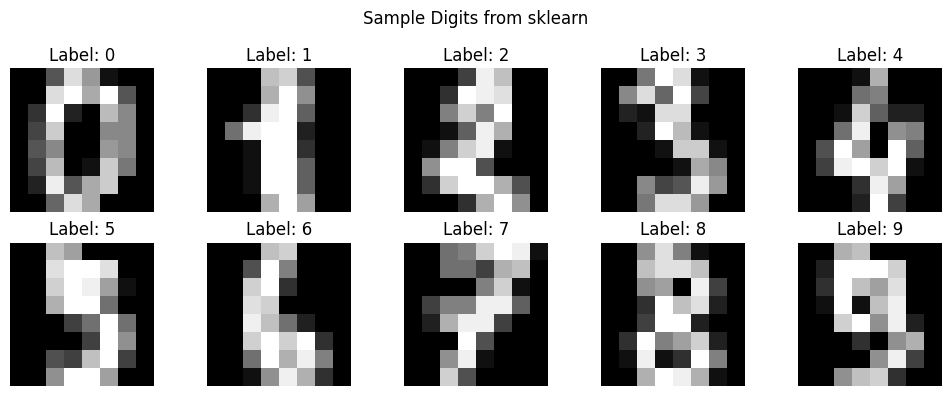

Train: (1437, 64), Test: (360, 64)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

digits = load_digits()
X, y = digits.data, digits.target  # X: (1797, 64), y: (1797,)

print(f"Dataset shape: {X.shape}, Labels: {np.unique(y)}")

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap="gray")
    ax.set_title(f"Label: {y[i]}")
    ax.axis("off")
plt.suptitle("Sample Digits from sklearn")
plt.tight_layout()
plt.show()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

### STEP 1.3 -- Single-Layer Perceptron (8 min)

```
z = W . x + b
```

- **x**: input vector (shape: 64)
- **W**: weight matrix (shape: 10 x 64)
- **b**: bias vector (shape: 10)
- **z**: raw logits (shape: 10)

Predicted class: `y_hat = argmax(z)`. This is equivalent to multinomial logistic regression.

### STEP 1.4 -- Activation Functions Deep Dive (12 min)

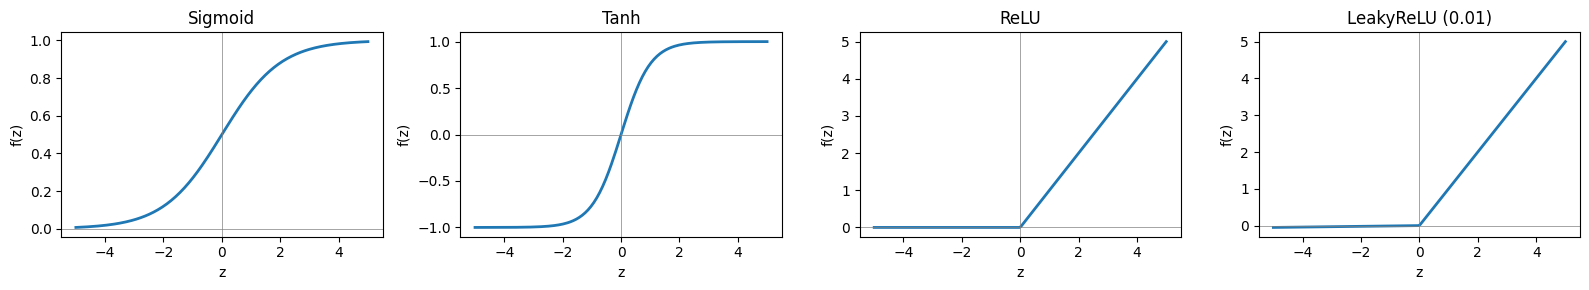

In [3]:
z = np.linspace(-5, 5, 200)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)

activations = {
    "Sigmoid": sigmoid(z),
    "Tanh": np.tanh(z),
    "ReLU": relu(z),
    "LeakyReLU (0.01)": leaky_relu(z, 0.01),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for ax, (name, vals) in zip(axes, activations.items()):
    ax.plot(z, vals, linewidth=2)
    ax.set_title(name)
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.axvline(0, color="gray", linewidth=0.5)
    ax.set_xlabel("z")
    ax.set_ylabel("f(z)")
plt.tight_layout()
plt.show()

---
## STAGE 2 -- MLPs, Backpropagation, and Gradient Descent (35 min)

### STEP 2.1 -- Backpropagation Walkthrough (12 min)

```
Input x --> [Linear + ReLU] --> h --> [Linear] --> logits --> CrossEntropyLoss --> L
```

Chain rule applied backward:
- dL/d(logits) -- from the loss
- dL/dW2 = dL/d(logits) . h^T
- dL/dh = W2^T . dL/d(logits)
- dL/d(pre_relu) = dL/dh * ReLU'(pre_relu)
- dL/dW1 = dL/d(pre_relu) . x^T

### STEP 2.2 -- Build an MLP (8 min)

| Configuration | Hidden Layers | Approx. Params | Trade-off |
|---------------|---------------|-----------------|----------|
| Wide-Shallow (1x512) | [512] | 38,410 | All features at one abstraction level |
| Narrow-Deep (4x32) | [32, 32, 32, 32] | 3,594 | Hierarchical; harder to train |
| Balanced (2x128) | [128, 128] | 26,122 | Good for small-medium datasets |
| Funnel (256-128-64) | [256, 128, 64] | ~42,000 | Progressive compression |

### STEP 2.3 -- Training Loop with Gradient Descent (10 min)

Five critical steps per mini-batch:
1. **Zero gradients**
2. **Forward pass** -- compute predictions
3. **Compute loss** -- cross-entropy for classification
4. **Backward pass** -- compute dL/dw via chain rule
5. **Optimizer step** -- w <- w - lr * dL/dw

---
**BREAK -- 10 min**

---

## STAGE 3 -- Regularization, Optimizers, and Early Stopping (40 min)

We switch to a **fraud detection** problem where class imbalance makes evaluation nontrivial.

### STEP 3.1 -- Introduce the Fraud Detection Dataset (5 min)

In [18]:
import pandas as pd
from sklearn.datasets import make_classification

np.random.seed(42)

X, y = make_classification(
    n_samples=10000,
    n_features=20,
    n_informative=12,
    n_redundant=4,
    n_classes=2,
    weights=[0.95, 0.05],
    flip_y=0.02,
    random_state=42
)

feature_names = [
    "txn_amount", "txn_hour", "merchant_risk", "distance_home",
    "avg_txn_30d", "txn_frequency", "card_age_days", "credit_util",
    "online_ratio", "foreign_txn", "amt_vs_avg", "velocity_1h",
    "prev_declines", "device_score", "geo_anomaly", "time_since_last",
    "weekend_flag", "high_risk_mcc", "ip_change_freq", "acct_balance",
]
df = pd.DataFrame(X, columns=feature_names)
df["is_fraud"] = y

print(f"Dataset shape: {df.shape}")
print(f"Class distribution:\n{df['is_fraud'].value_counts(normalize=True)}")

X_all = df.drop("is_fraud", axis=1).values
y_all = df["is_fraud"].values

X_temp, X_test, y_temp, y_test = train_test_split(
    X_all, y_all, test_size=0.15, stratify=y_all, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, stratify=y_temp, random_state=42
)

print(f"\nSplit sizes -> Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")
print(f"Train fraud rate: {y_train.mean():.4f}")
print(f"Val fraud rate:   {y_val.mean():.4f}")
print(f"Test fraud rate:  {y_test.mean():.4f}")

Dataset shape: (10000, 21)
Class distribution:
is_fraud
0    0.9406
1    0.0594
Name: proportion, dtype: float64

Split sizes -> Train: 7004, Val: 1496, Test: 1500
Train fraud rate: 0.0594
Val fraud rate:   0.0595
Test fraud rate:  0.0593


### STEP 3.2 -- L1 (Lasso) and L2 (Ridge) Regularization (5 min)

- **L2 (Ridge)**: `lambda * sum(w^2)` -- shrinks all coefficients toward zero
- **L1 (Lasso)**: `lambda * sum(|w|)` -- drives some coefficients to exactly zero
- In sklearn, `C = 1 / lambda`. Smaller C = stronger regularization.

In [19]:
from sklearn.linear_model import LogisticRegression

ridge_model = LogisticRegression(
    penalty="l2", C=1.0, max_iter=1000, solver="lbfgs", random_state=42
)
ridge_model.fit(X_train, y_train)

lasso_model = LogisticRegression(
    penalty="l1", C=1.0, max_iter=1000, solver="saga", random_state=42
)
lasso_model.fit(X_train, y_train)

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Ridge (L2)": ridge_model.coef_[0],
    "Lasso (L1)": lasso_model.coef_[0]
})
coef_df["L1_is_zero"] = np.abs(coef_df["Lasso (L1)"]) < 1e-6
print(coef_df.to_string(index=False))
print(f"\nFeatures zeroed out by Lasso: {coef_df['L1_is_zero'].sum()} / {len(feature_names)}")

        Feature  Ridge (L2)  Lasso (L1)  L1_is_zero
     txn_amount    0.034538    0.032415       False
       txn_hour   -0.034811    0.000167       False
  merchant_risk    0.016123    0.000000        True
  distance_home    0.456357    0.502504       False
    avg_txn_30d    0.094505    0.049867       False
  txn_frequency   -0.173538   -0.200938       False
  card_age_days   -0.198013   -0.098124       False
    credit_util    0.163281    0.174086       False
   online_ratio   -0.056801    0.000000        True
    foreign_txn    0.217694    0.173736       False
     amt_vs_avg    0.111451    0.039374       False
    velocity_1h    0.028430    0.024983       False
  prev_declines   -0.226263   -0.247910       False
   device_score   -0.067039   -0.102045       False
    geo_anomaly   -0.020870   -0.017140       False
time_since_last    0.010960    0.000000        True
   weekend_flag   -0.023949    0.000000        True
  high_risk_mcc    0.207154    0.232001       False
 ip_change_f

### STEP 3.3 -- Dropout Regularization (5 min)

Dropout is a neural network technique presented as pseudocode (framework-agnostic).

| Model | Training Loss | Validation Loss | Gap |
|-------|--------------|-----------------|-----|
| Without Dropout | Decreases to near zero | Decreases then increases | Large (overfitting) |
| With Dropout (0.3) | Decreases more slowly | Stays close to training | Small (better generalization) |

**Critical**: Dropout is ONLY active during training. At inference, all neurons are active but outputs are scaled by `(1 - drop_rate)`.

### STEP 3.4 -- Optimizers: SGD vs. Adam (12 min)

| Criterion | SGD (+ Momentum) | Adam |
|-----------|-------------------|------|
| Convergence speed | Slower | Faster |
| Hyperparameter sensitivity | High (lr critical) | More forgiving |
| Generalization | Often slightly better | Can find sharper minima |
| Memory | Lower | 2x parameter memory |
| Common use | Large-scale vision, tuning | NLP, GANs, prototyping |

### STEP 3.5 -- Early Stopping (8 min)

- **Patience**: epochs to wait without improvement
- **min_delta**: minimum change to count as improvement
- **Weight restoration**: deploy the model from the *best* epoch, not the last

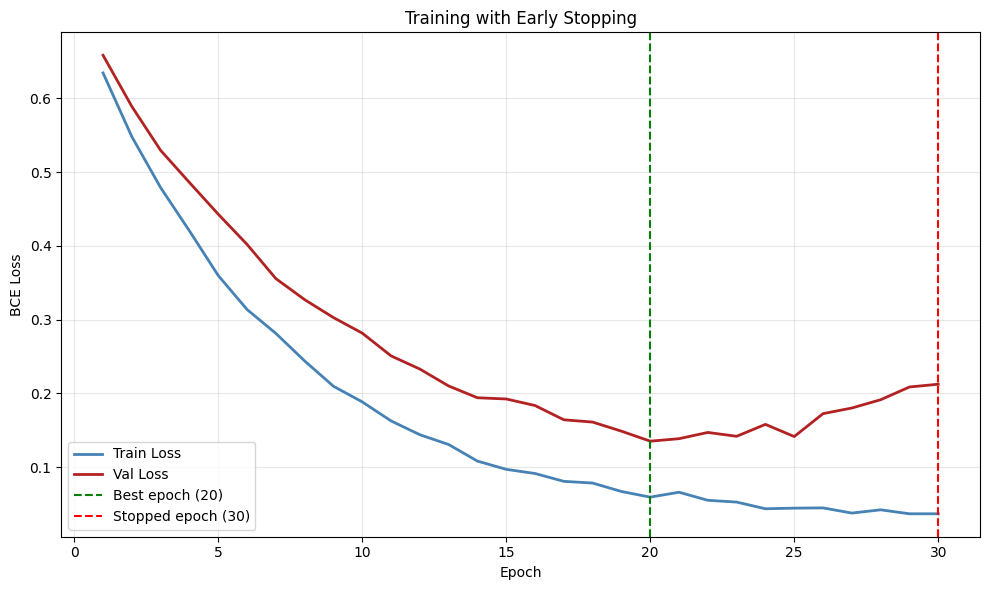

In [20]:
np.random.seed(42)

n_epochs = 50
best_epoch = 20
stopped_epoch = 30

epochs = np.arange(1, n_epochs + 1)

train_loss = 0.7 * np.exp(-0.15 * epochs) + 0.03 + np.random.normal(0, 0.004, n_epochs)

val_decay = 0.65 * np.exp(-0.12 * epochs)
val_overfit = 0.004 * np.maximum(epochs - best_epoch, 0) ** 1.5
val_loss = val_decay + 0.08 + val_overfit + np.random.normal(0, 0.006, n_epochs)

train_loss_shown = train_loss[:stopped_epoch]
val_loss_shown = val_loss[:stopped_epoch]
epochs_shown = epochs[:stopped_epoch]

plt.figure(figsize=(10, 6))
plt.plot(epochs_shown, train_loss_shown, label="Train Loss", color="steelblue", linewidth=2)
plt.plot(epochs_shown, val_loss_shown, label="Val Loss", color="firebrick", linewidth=2)
plt.axvline(x=best_epoch, color="green", linestyle="--", linewidth=1.5,
            label=f"Best epoch ({best_epoch})")
plt.axvline(x=stopped_epoch, color="red", linestyle="--",
            linewidth=1.5, label=f"Stopped epoch ({stopped_epoch})")
plt.title("Training with Early Stopping")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
**BREAK -- 10 min**

---

## STAGE 4 -- Evaluation Metrics and Explainability (40 min)

We have a trained fraud detection model with regularization and early stopping. How do we know if it is actually good?

### STEP 4.1 -- Train the Evaluation Model (3 min)

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

eval_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        penalty="l2",
        C=1.0,
        max_iter=1000,
        class_weight={0: 1, 1: 8},
        random_state=42
    ))
])

eval_pipeline.fit(X_train, y_train)

y_val_pred = eval_pipeline.predict(X_val)
y_val_proba = eval_pipeline.predict_proba(X_val)[:, 1]

y_test_pred = eval_pipeline.predict(X_test)
y_test_proba = eval_pipeline.predict_proba(X_test)[:, 1]

print("Model trained. Predictions generated on validation and test sets.")

Model trained. Predictions generated on validation and test sets.


### STEP 4.2 -- Precision, Recall, and F1 (12 min)

- **Precision = TP / (TP + FP)**: Of all flagged as fraud, what fraction actually were?
- **Recall = TP / (TP + FN)**: Of all actual fraud, what fraction did we catch?
- **F1 = 2 * Precision * Recall / (Precision + Recall)**: Harmonic mean

In [27]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("=== Test Set Metrics (Fraud = Positive Class) ===")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1 Score:  {f1:.4f}")
print()
print("Full Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=["Legitimate", "Fraud"]))

=== Test Set Metrics (Fraud = Positive Class) ===
  Precision: 0.5370
  Recall:    0.3258
  F1 Score:  0.4056

Full Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.96      0.98      0.97      1411
       Fraud       0.54      0.33      0.41        89

    accuracy                           0.94      1500
   macro avg       0.75      0.65      0.69      1500
weighted avg       0.93      0.94      0.94      1500



In [28]:
tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()

print("=== Manual Calculation ===")
print(f"  True Positives  (caught fraud):       {tp}")
print(f"  False Positives (false alarms):        {fp}")
print(f"  True Negatives  (correct legitimate):  {tn}")
print(f"  False Negatives (missed fraud):         {fn}")
print()
manual_precision = tp / (tp + fp) if (tp + fp) > 0 else 0
manual_recall = tp / (tp + fn) if (tp + fn) > 0 else 0
manual_f1 = (2 * manual_precision * manual_recall /
             (manual_precision + manual_recall)
             if (manual_precision + manual_recall) > 0 else 0)
print(f"  Manual Precision: {manual_precision:.4f}")
print(f"  Manual Recall:    {manual_recall:.4f}")
print(f"  Manual F1:        {manual_f1:.4f}")

=== Manual Calculation ===
  True Positives  (caught fraud):       29
  False Positives (false alarms):        25
  True Negatives  (correct legitimate):  1386
  False Negatives (missed fraud):         60

  Manual Precision: 0.5370
  Manual Recall:    0.3258
  Manual F1:        0.4056


### STEP 4.3 -- Confusion Matrix and AUC-ROC (13 min)

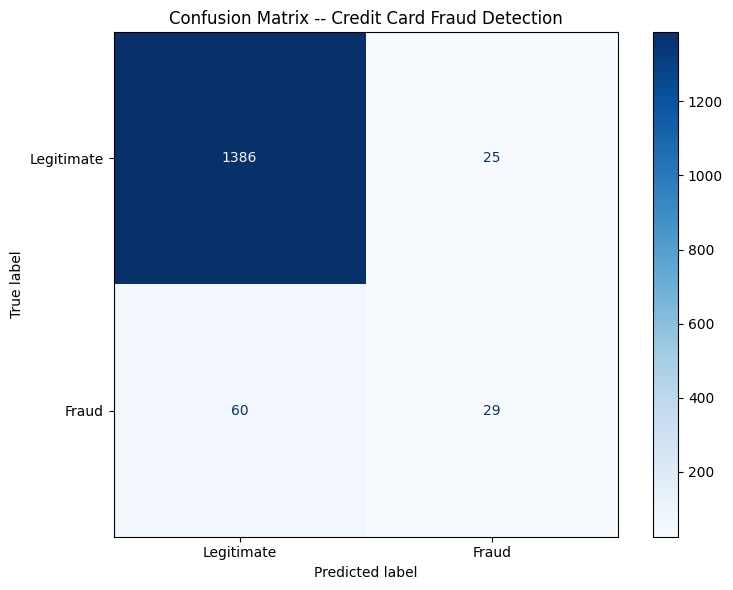

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred,
    display_labels=["Legitimate", "Fraud"],
    cmap="Blues",
    ax=ax,
    values_format="d"
)
ax.set_title("Confusion Matrix -- Credit Card Fraud Detection")
plt.tight_layout()
plt.show()

AUC-ROC Score: 0.8217


C:\Users\CharlesJester\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


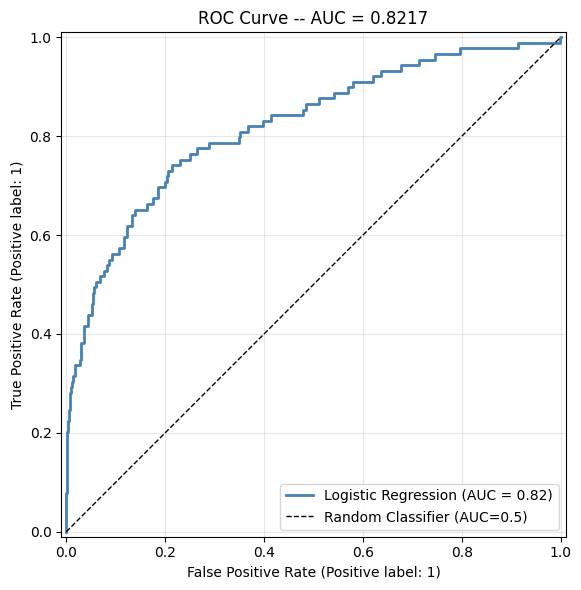

In [30]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

auc_score = roc_auc_score(y_test, y_test_proba)
print(f"AUC-ROC Score: {auc_score:.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(
    y_test, y_test_proba,
    name="Logistic Regression",
    ax=ax,
    color="steelblue",
    linewidth=2
)
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier (AUC=0.5)")
ax.set_title(f"ROC Curve -- AUC = {auc_score:.4f}")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

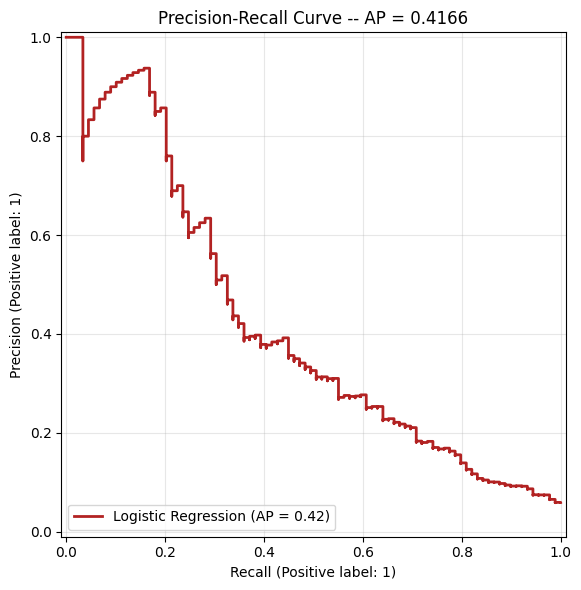

Average Precision Score: 0.4166


In [13]:
from sklearn.metrics import average_precision_score, PrecisionRecallDisplay

ap_score = average_precision_score(y_test, y_test_proba)

fig, ax = plt.subplots(figsize=(8, 6))
PrecisionRecallDisplay.from_predictions(
    y_test, y_test_proba,
    name="Logistic Regression",
    ax=ax,
    color="firebrick",
    linewidth=2
)
ax.set_title(f"Precision-Recall Curve -- AP = {ap_score:.4f}")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Average Precision Score: {ap_score:.4f}")

### STEP 4.4 -- SHAP Values for Model Explainability (10 min)

In [14]:
import shap

explainer = shap.LinearExplainer(
    eval_pipeline.named_steps["classifier"],
    eval_pipeline.named_steps["scaler"].transform(X_train),
    feature_names=feature_names
)

X_test_scaled = eval_pipeline.named_steps["scaler"].transform(X_test)
shap_values = explainer.shap_values(X_test_scaled)

print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (1500, 20)


C:\Users\CharlesJester\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\CharlesJester\AppData\Local\Temp\ipykernel_13156\1892940407.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names, show=False)


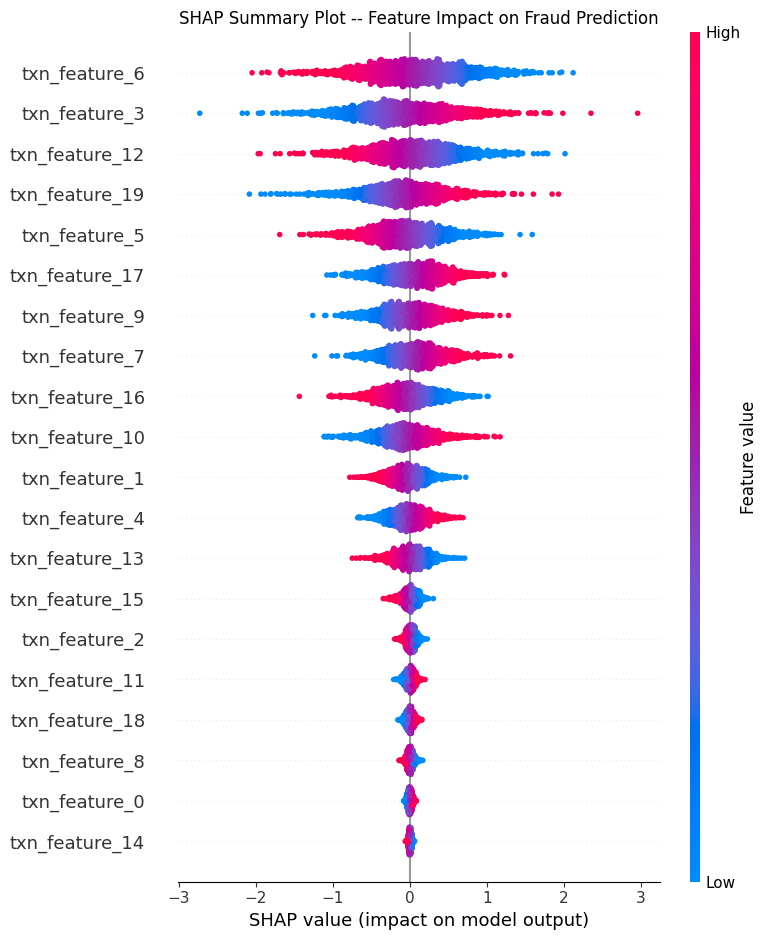

In [15]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot -- Feature Impact on Fraud Prediction")
plt.tight_layout()
plt.show()

C:\Users\CharlesJester\AppData\Local\Temp\ipykernel_13156\3661706497.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names,


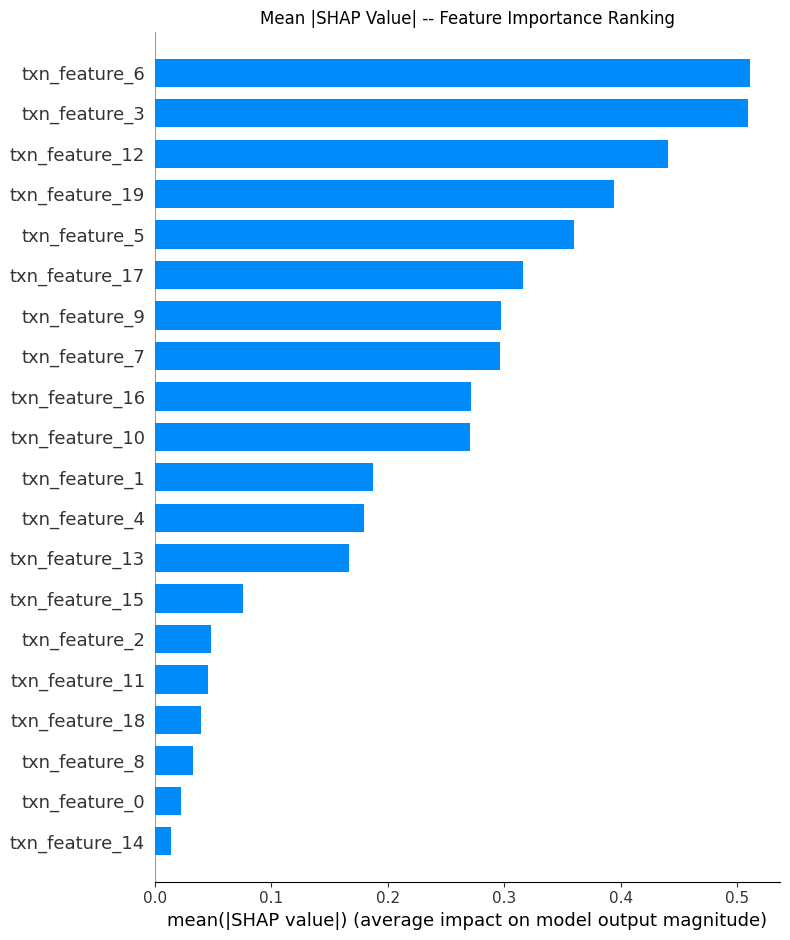

In [16]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names,
                  plot_type="bar", show=False)
plt.title("Mean |SHAP Value| -- Feature Importance Ranking")
plt.tight_layout()
plt.show()

---
## Session Recap

| # | Topic | Key Takeaway |
|---|-------|--------------|
| 1 | Perceptrons & Activation | ReLU is the modern default; sigmoid/tanh vanish |
| 2 | MLPs: Width vs. Depth | Width = capacity; depth = hierarchical features |
| 3 | Backpropagation | Chain rule from loss backward through layers |
| 4 | Regularization | L2 shrinks, L1 zeroes, Dropout builds redundancy |
| 5 | Optimizers | Adam converges faster; SGD can generalize better |
| 6 | Early Stopping | Monitor val loss; restore best weights |
| 7 | Precision, Recall, F1 | Precision = flagged correctly; Recall = caught |
| 8 | AUC-ROC | Threshold-independent model comparison |
| 9 | SHAP | Per-feature, per-prediction contribution scores |